## ELE632 Lab 3
#### Terry Chen 501236148

In [83]:
import numpy as np
import matplotlib.pyplot as plt

#### Part A: Discrete-Time Fourier Series
#### A.2)
$$x[n] = 4 \sin (2.4\pi n) + 2 \cos (3.2\pi n)$$

#### solving for the fundamental period:
$$\frac{\omega}{2\pi} = \frac{m}{N}$$
$4 \sin(2.4\pi n): \omega_1 = 2.4\pi$ $$\frac{2.4\pi}{2\pi} = \frac{6}{5}$$ 
$2 \cos(3.2\pi n): \omega_2 = 3.2\pi$ $$\frac{3.2\pi}{2\pi} = \frac{8}{5}$$
$\therefore N_1, N_2 = 5 \rightarrow LCM(5, 5) = 5 \rightarrow N_0 = 5$

#### solving for the fundamental frequency:
$$\Omega_0 = \frac{2\pi}{N_0} = \frac{2\pi}{5} = 0.4\pi$$

#### A.3)

by examining the plot $y[n]$: 
$$ N_0 = 6$$
$$\Omega_0 = \frac{2\pi}{6} = 0.33\pi$$



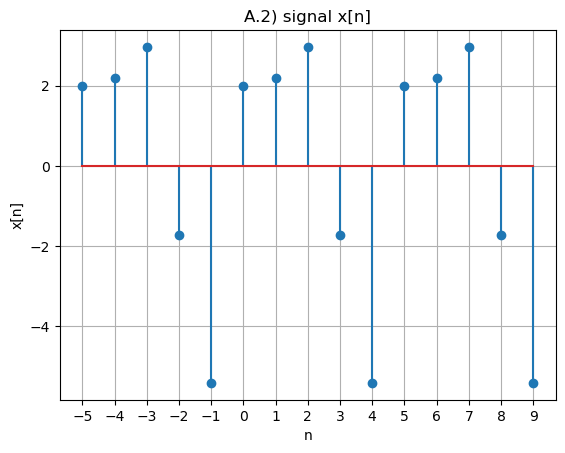

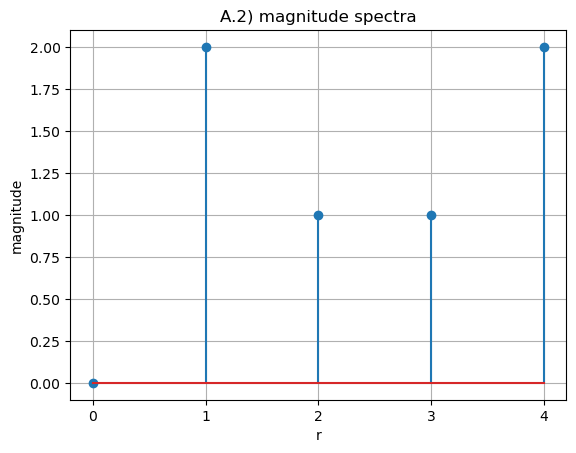

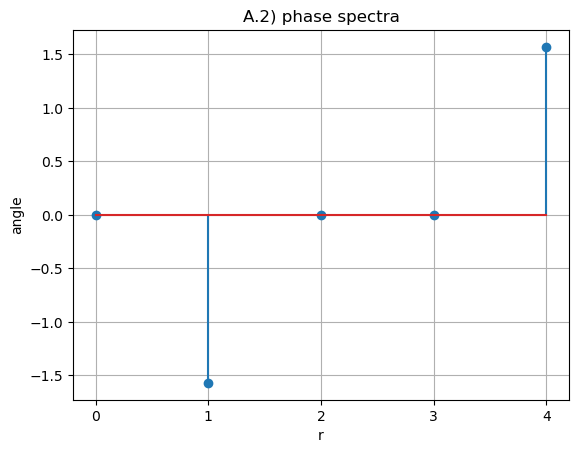

In [85]:
# A.2) x[n]
xn_range = np.arange(-5, 10)
xn = 4 * np.sin(2.4 * np.pi * xn_range) + 2 * np.cos(3.2 * np.pi * xn_range)

n0 = 5
w0 = 0.4 * np.pi
r_idx = np.arange(n0)

# Dr = (1/N0) * sum(x[n] * exp(-j * r * w0 * n))
Dr = np.zeros(n0, dtype=complex)

for r in range(n0):
    # summation from 0 to N0-1
    Dr[r] = (1/n0) * np.sum(xn_period * np.exp(-1j * r * w0 * r_idx))

mag_Dr = np.abs(Dr)
phase_Dr = np.angle(Dr)

plt.figure()
plt.stem(xn_range, xn)
plt.xticks(np.arange(min(xn_range), max(xn_range)+1, 1))
plt.title('A.2) signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

plt.figure()
plt.stem(r_idx, mag_Dr)
plt.xticks(np.arange(min(r_idx), max(r_idx)+1, 1))
plt.title('A.2) magnitude spectra')
plt.xlabel('r')
plt.ylabel('magnitude')
plt.grid()
plt.show()

plt.figure()
plt.stem(r_idx, phase_Dr)
plt.xticks(np.arange(min(r_idx), max(r_idx)+1, 1))
plt.title('A.2) phase spectra')
plt.xlabel('r')
plt.ylabel('angle')
plt.grid()
plt.show()


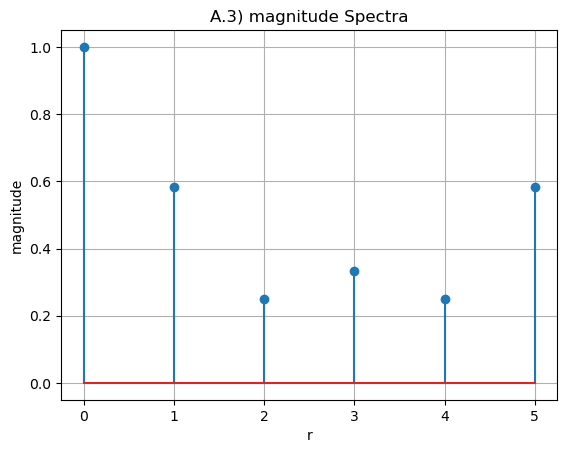

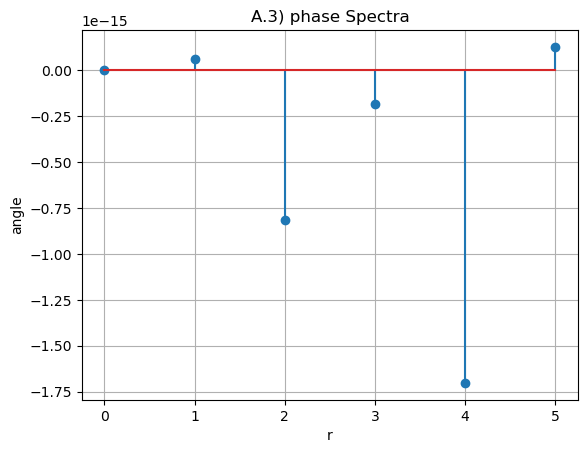

In [99]:
# A.3) y[n]
n0_y = 6
w0_y = (2/6) * np.pi
r_idx_y = np.arange(n0_y)

# values in 1 period (approximated values based on plot)
yn_period = np.array([3, 1, 0.5, 0, 0.5, 1])

# Dr for y[n]
# Dr = (1/N0) * sum(y[n] * exp(-j * r * w0 * n))
Dr_y = np.zeros(n0_y, dtype=complex)

for r in range(n0_y):
    # summation from 0 to N0-1
    Dr_y[r] = (1/n0_y) * np.sum(yn_period * np.exp(-1j * r * w0_y * r_idx_y))

mag_Dr_y = np.abs(Dr_y)
phase_Dr_y = np.angle(Dr_y)


plt.figure()
plt.stem(r_idx_y, mag_Dr_y)
plt.xticks(np.arange(min(r_idx_y), max(r_idx_y)+1, 1))
plt.title('A.3) magnitude Spectra')
plt.xlabel('r')
plt.ylabel('magnitude')
plt.grid()

plt.figure()
plt.stem(r_idx_y, phase_Dr_y)
plt.xticks(np.arange(min(r_idx_y), max(r_idx_y)+1, 1))
plt.title('A.3) phase Spectra')
plt.xlabel('r')
plt.ylabel('angle')
plt.grid()

#### Part B: Inverse DTFS and time shifting property
* $D = 2$

by examining the plot: 
$$ N_0 = 32$$
$$\Omega_0 = \frac{2\pi}{32} = \frac{1}{16}\pi$$

the inverse DTFS formula as seen in the lab manual is:
$$x[n] = \sum_{r=0}^{N_0-1} D_r e^{j r \Omega_0 n}$$

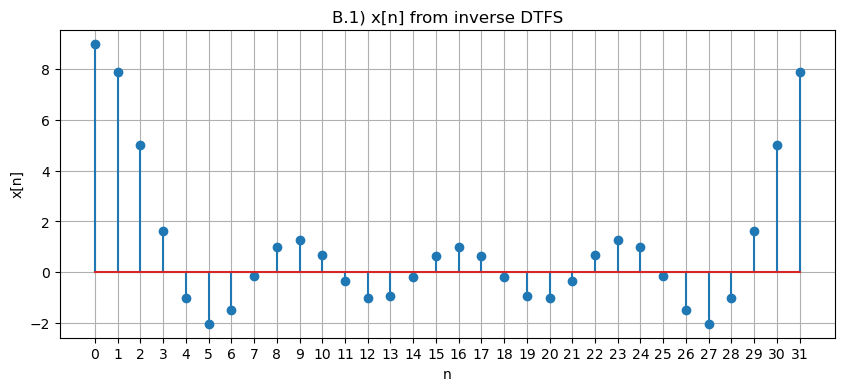

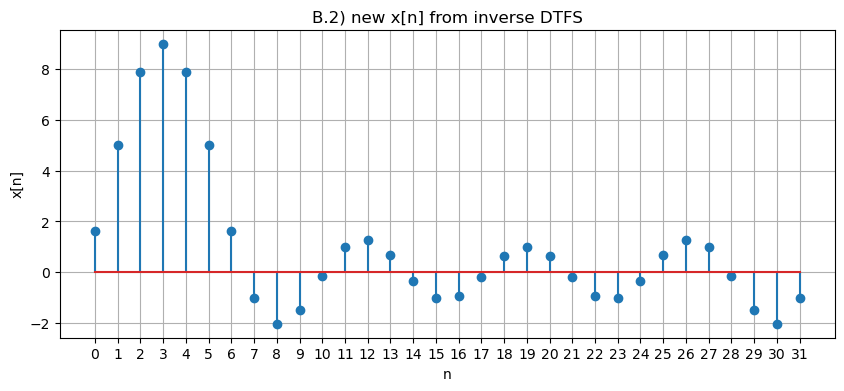

In [100]:
n0 = 32
w0 = (2/32) * np.pi
n_idx = np.arange(n0)
r_idx = np.arange(-16, 16) 

# mag = 1 from -4 to 4
Dr = ((r_idx >= -4) * (r_idx <= 4)) * (np.mod(n,1)==0) * 1


# IDTFS: x[n] = sum(Dr * exp(j * r * w0 * n))
xn = np.zeros(n0, dtype=complex)

for n in n_idx:
    xn[n] = np.sum(Dr * np.exp(1j * r_idx * w0 * n))

plt.figure(figsize=(10, 4))
plt.stem(n_idx, xn.real) # resolves ComplexWarning (casting complex values to real)
plt.title('B.1) x[n] from inverse DTFS')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.xticks(np.arange(min(n_idx), max(n_idx)+1, 1))
plt.show()

# B.2)
D = 2
Dr_new = Dr * np.exp(-1j * (D + 1) * w0 * r_idx)
xn_new = np.zeros(n0, dtype=complex)

for n in n_idx:
    xn_new[n] = np.sum(Dr_new * np.exp(1j * r_idx * w0 * n))

plt.figure(figsize=(10, 4))
plt.stem(n_idx, xn_new.real)
plt.title('B.2) new x[n] from inverse DTFS')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.xticks(np.arange(min(n_idx), max(n_idx)+1, 1))
plt.show()

#### Part C: System Response

$$ N_0 = 32$$
$$\Omega_0 = \frac{2\pi}{32} = \frac{1}{16}\pi$$

#### C.2)

$$ x_1[n] = 4\cos(\frac{\pi n}{8})$$

#### C.3)

$$ x_2[n] = 4\cos(\frac{\pi n}{3})$$

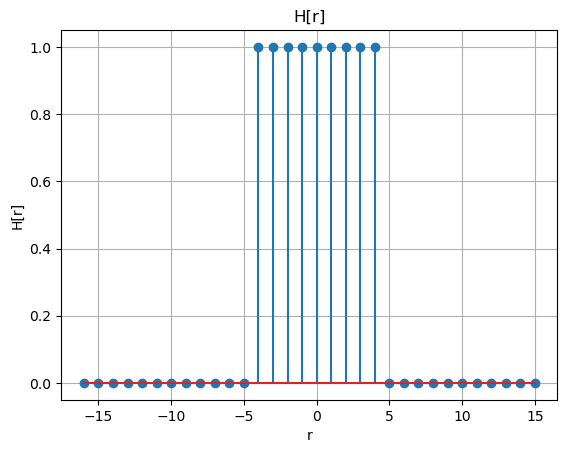

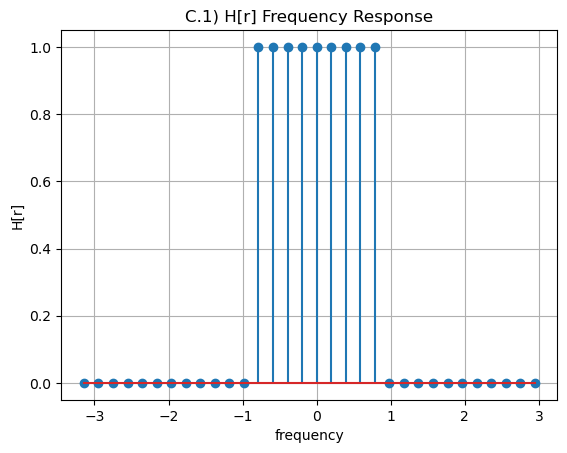

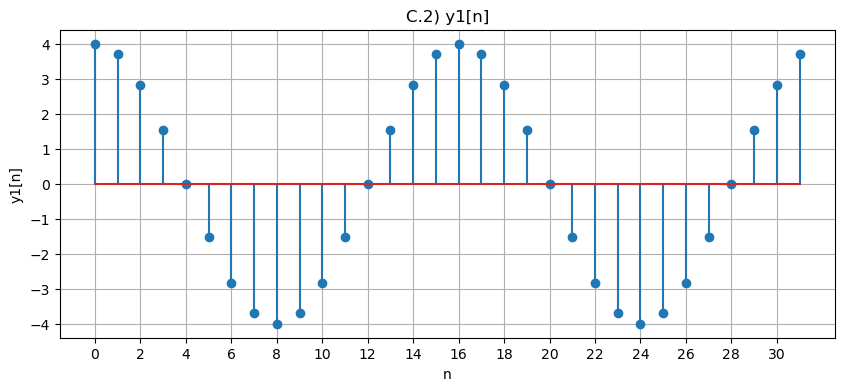

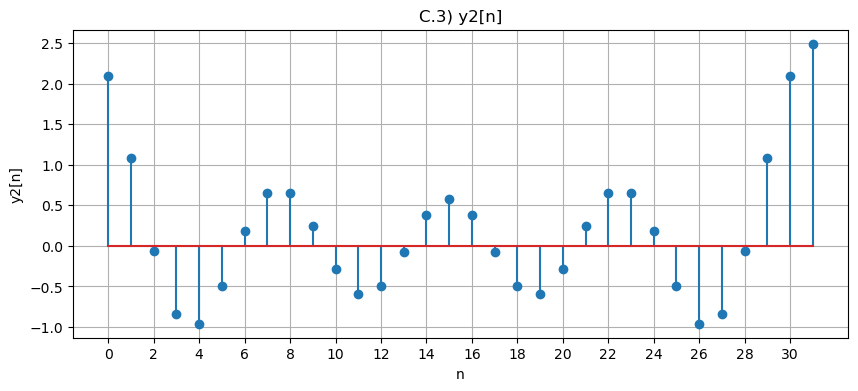

In [98]:
n0 = 32
w0 = (2/32) * np.pi
r_idx = np.arange(-16, 16)
n_idx = np.arange(n0)

# H[r]
Hr = ((r_idx >= -4) * (r_idx <= 4)) * (np.mod(n,1)==0) * 1

plt.figure()
plt.stem(r_idx, Hr)
plt.title('H[r]')
plt.xlabel('r')
plt.ylabel('H[r]')
plt.grid()
plt.show()

plt.figure()
plt.stem(r_idx * w0, Hr) # Plotting with respect to Omega0 * r
plt.title('C.1) H[r] Frequency Response')
plt.xlabel('frequency')
plt.ylabel('H[r]')
plt.grid()
plt.show()

# C.2)
x1_n = 4 * np.cos((np.pi * n_idx) / 8)
X1_r = np.zeros(n0, dtype=complex)

for r in range(n0):
    X1_r[r] = (1/n0) * np.sum(x1_n * np.exp(-1j * r_idx[r] * w0 * n_idx))

Y1_r = X1_r * Hr # system response

# inverse DTFS
y1_n = np.zeros(n0, dtype=complex)
for n in n_idx:
    y1_n[n] = np.sum(Y1_r * np.exp(1j * r_idx * w0 * n))

plt.figure(figsize=(10,4))
plt.stem(n_idx, y1_n.real)
plt.title('C.2) y1[n]')
plt.xlabel('n')
plt.ylabel('y1[n]')
plt.grid()
plt.xticks(np.arange(min(n_idx), max(n_idx)+1, 2))
plt.show()

# C.3)
x2_n = 4 * np.cos((np.pi * n_idx) / 3)
X2_r = np.zeros(n0, dtype=complex)

for r in range(n0):
    X2_r[r] = (1/n0) * np.sum(x2_n * np.exp(-1j * r_idx[r] * w0 * n_idx))

Y2_r = X2_r * Hr # system response

# inverse DTFS
y2_n = np.zeros(n0, dtype=complex)
for n in n_idx:
    y2_n[n] = np.sum(Y2_r * np.exp(1j * r_idx * w0 * n))

plt.figure(figsize=(10,4))
plt.stem(n_idx, y2_n.real)
plt.title('C.3) y2[n]')
plt.xlabel('n')
plt.ylabel('y2[n]')
plt.grid()
plt.xticks(np.arange(min(n_idx), max(n_idx)+1, 2))
plt.show()